# Datathon 2026 EDA Workload

This notebook performs the exploratory data analysis described in `eda_work.md`.
Given the large size of the dataset (e.g., `fact_user_events` has ~161M rows), we use **DuckDB** to directly query the Parquet files efficiently without loading them entirely into memory.

## Setup and Data Pathways
Initializing DuckDB and defining pathways.

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

# Base Path
BASE_DATA_DIR = r"d:\Desktop_informations\Datathon\Datathon2026-Deep67-Finals\datathon_2026_processed"

# Pathways
PATHS = {
    "dim_listing": os.path.join(BASE_DATA_DIR, "train_clean", "dim_listing", "dim_listing_cleaned.parquet"),
    "fact_listing": os.path.join(BASE_DATA_DIR, "train_clean", "fact_listing_snapshot", "fact_listing_snapshot_cleaned.parquet"),
    "user_ad_interactions": os.path.join(BASE_DATA_DIR, "train_clean", "fact_user_ad_interactions", "*.parquet"),
    "user_events": os.path.join(BASE_DATA_DIR, "train_clean", "fact_user_events", "**", "*.parquet"),
    "test_users": os.path.join(BASE_DATA_DIR, "test", "test_users.parquet")
}

# Initialize DuckDB connection
con = duckdb.connect(database=':memory:')
print("DuckDB initialized.")

DuckDB initialized.


## Phase 1: Global Dataset Profiling & The Baseline "Feel"
Goal: Understand the size, shape, and fundamental distributions of the universe.

### Temporal Coverage & Gaps
Plot the count of all events as a daily time series to identify holidays like Tet.

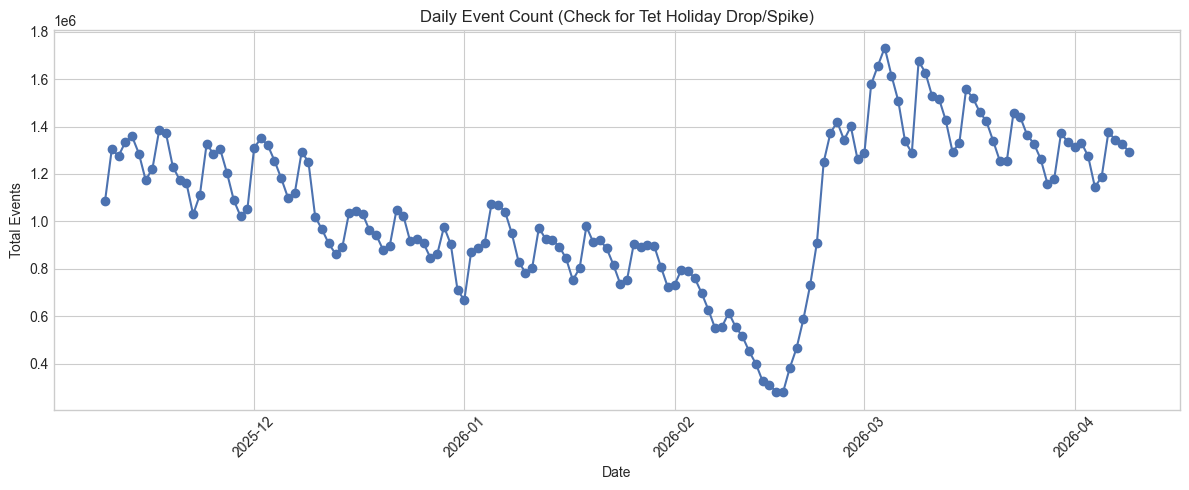

In [2]:
query = f"""
SELECT 
    CAST(event_ts AS DATE) as event_date,
    COUNT(*) as total_events
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
GROUP BY 1
ORDER BY 1
"""
df_temporal = con.execute(query).df()

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(df_temporal['event_date']), df_temporal['total_events'], marker='o', linestyle='-')
plt.title('Daily Event Count (Check for Tet Holiday Drop/Spike)')
plt.xlabel('Date')
plt.ylabel('Total Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interaction Sparsity & Distribution
Calculate unique users, items, and total vs positive events.

In [3]:
positive_events = ('view_phone', 'contact_chat', 'other_interaction', 'contact_zalo', 'contact_sms')
positive_events_str = ", ".join([f"'{e}'" for e in positive_events])

query_sparsity = f"""
SELECT
    COUNT(DISTINCT user_id) as unique_users,
    COUNT(DISTINCT item_id) as unique_items,
    COUNT(*) as total_events,
    SUM(CASE WHEN event_type IN ({positive_events_str}) THEN 1 ELSE 0 END) as positive_events
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
"""
df_sparsity = con.execute(query_sparsity).df()
display(df_sparsity)

if df_sparsity['total_events'][0] > 0:
    base_cr = (df_sparsity['positive_events'][0] / df_sparsity['total_events'][0]) * 100
    print(f"Base Contact Rate: {base_cr:.2f}%")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,unique_users,unique_items,total_events,positive_events
0,3326120,758546,161731336,96182413.0


Base Contact Rate: 59.47%


## Phase 2: In-Depth Temporal & User Behavior Dynamics
Uncover the "why" and "when" of positive interactions.

### The Conversion Funnel
Extract clickstream leading up to positive events.

In [4]:
# Example: Sample 1000 users who had a positive event and look at their event distribution
query_funnel = f"""
WITH pos_users AS (
    SELECT DISTINCT user_id
    FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
    WHERE event_type IN ({positive_events_str})
    LIMIT 1000
)
SELECT 
    event_type,
    COUNT(*) as count
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true) e
JOIN pos_users pu ON e.user_id = pu.user_id
GROUP BY 1
ORDER BY 2 DESC
"""
df_funnel = con.execute(query_funnel).df()
display(df_funnel)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,count
0,other_interaction,164434
1,pageview,91757
2,view_phone,5747
3,contact_chat,1695
4,contact_zalo,332
5,contact_sms,152


### Day of Week & Hour of Day Heatmap
Are certain events more common on weekends or evenings?

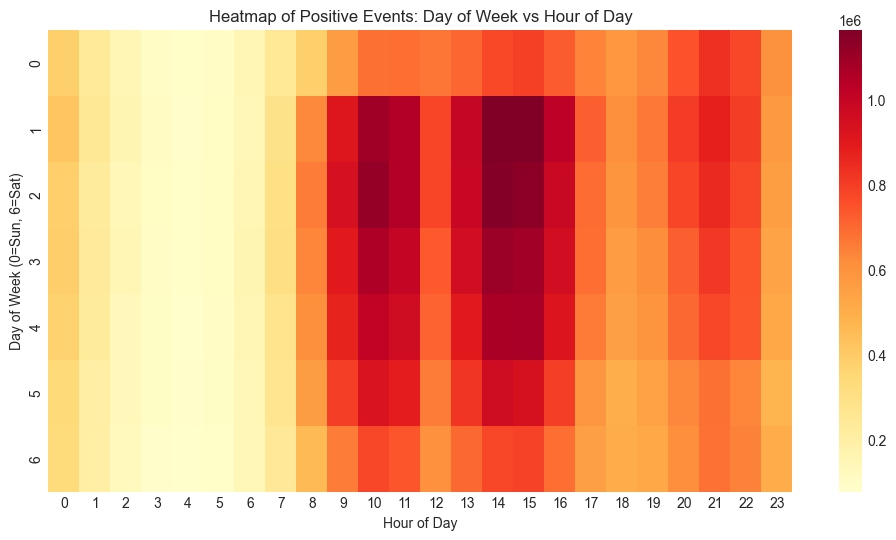

In [5]:
query_heatmap = f"""
SELECT 
    DAYOFWEEK(CAST(event_ts AS TIMESTAMP)) as day_of_week,
    EXTRACT(HOUR FROM CAST(event_ts AS TIMESTAMP)) as hour_of_day,
    COUNT(*) as event_count
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
WHERE event_type IN ({positive_events_str})
GROUP BY 1, 2
"""
df_heatmap = con.execute(query_heatmap).df()

if not df_heatmap.empty:
    heatmap_data = df_heatmap.pivot(index='day_of_week', columns='hour_of_day', values='event_count').fillna(0)
    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data, cmap='YlOrRd')
    plt.title('Heatmap of Positive Events: Day of Week vs Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Day of Week (0=Sun, 6=Sat)')
    plt.show()

## Phase 3: Listing & Content Dynamics
Understand what makes a listing "contactable".

### The Freshness Curve
Listing age vs lead count.

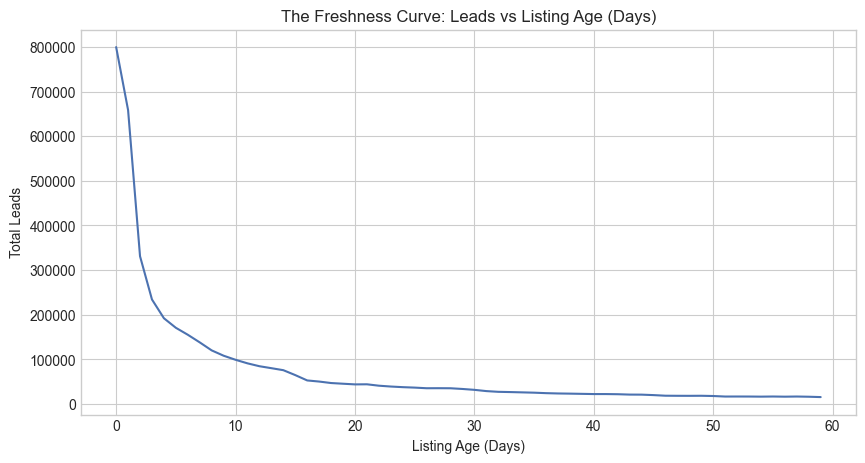

In [6]:
query_freshness = f"""
SELECT 
    listing_age_days,
    SUM(contacts_24h) as total_leads
FROM read_parquet('{PATHS['fact_listing']}')
WHERE listing_age_days IS NOT NULL AND listing_age_days >= 0 AND listing_age_days < 60
GROUP BY 1
ORDER BY 1
"""
df_freshness = con.execute(query_freshness).df()

plt.figure(figsize=(10, 5))
plt.plot(df_freshness['listing_age_days'], df_freshness['total_leads'])
plt.title('The Freshness Curve: Leads vs Listing Age (Days)')
plt.xlabel('Listing Age (Days)')
plt.ylabel('Total Leads')
plt.show()

### Long-Tail Item Exposure
Lorenz curve to see if a few items get all the views.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

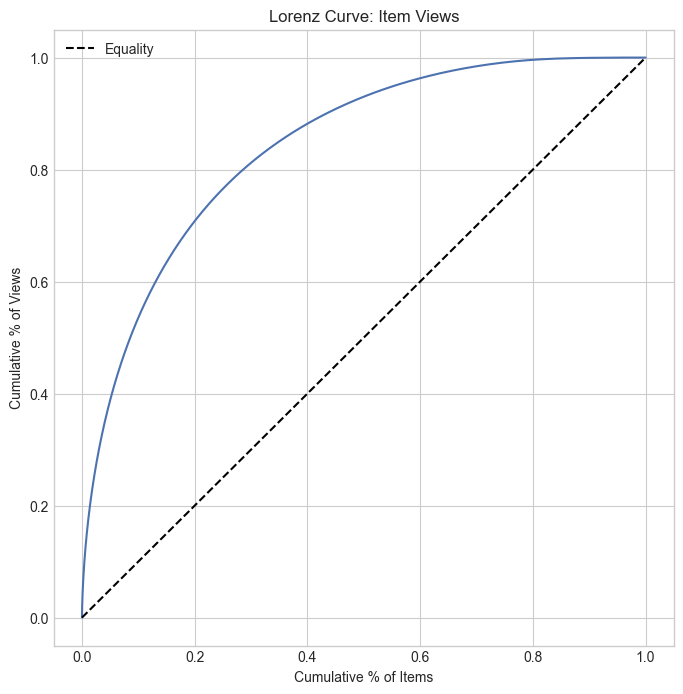

In [7]:
query_longtail = f"""
SELECT 
    item_id,
    SUM(views_24h) as total_views
FROM read_parquet('{PATHS['fact_listing']}')
GROUP BY 1
ORDER BY 2 DESC
"""
df_longtail = con.execute(query_longtail).df()

if not df_longtail.empty:
    df_longtail['cum_views'] = df_longtail['total_views'].cumsum()
    df_longtail['cum_views_pct'] = df_longtail['cum_views'] / df_longtail['total_views'].sum()
    df_longtail['item_pct'] = (df_longtail.reset_index().index + 1) / len(df_longtail)
    
    plt.figure(figsize=(8, 8))
    plt.plot(df_longtail['item_pct'], df_longtail['cum_views_pct'])
    plt.plot([0, 1], [0, 1], 'k--', label='Equality')
    plt.title('Lorenz Curve: Item Views')
    plt.xlabel('Cumulative % of Items')
    plt.ylabel('Cumulative % of Views')
    plt.legend()
    plt.show()

## Phase 4: Concept Drift & Train/Test Gap
Comparing the last 30 days of training with the 30 days before that.

In [8]:
query_drift = f"""
WITH daily_counts AS (
    SELECT 
        CAST(event_ts AS DATE) as dt,
        SUM(CASE WHEN event_type IN ({positive_events_str}) THEN 1 ELSE 0 END) as pos_events
    FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
    GROUP BY 1
)
SELECT 
    CASE 
        WHEN dt BETWEEN DATE '2026-03-10' AND DATE '2026-04-09' THEN 'Last 30 Days'
        WHEN dt BETWEEN DATE '2026-02-08' AND DATE '2026-03-09' THEN 'Prior 30 Days'
        ELSE 'Other'
    END as period,
    AVG(pos_events) as avg_daily_pos_events
FROM daily_counts
WHERE dt >= DATE '2026-02-08'
GROUP BY 1
"""
df_drift = con.execute(query_drift).df()
display(df_drift)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,period,avg_daily_pos_events
0,Last 30 Days,806502.806452
1,Prior 30 Days,579117.166667


### The "Silent Period" Challenge
For users in the test set, when was their last activity?

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

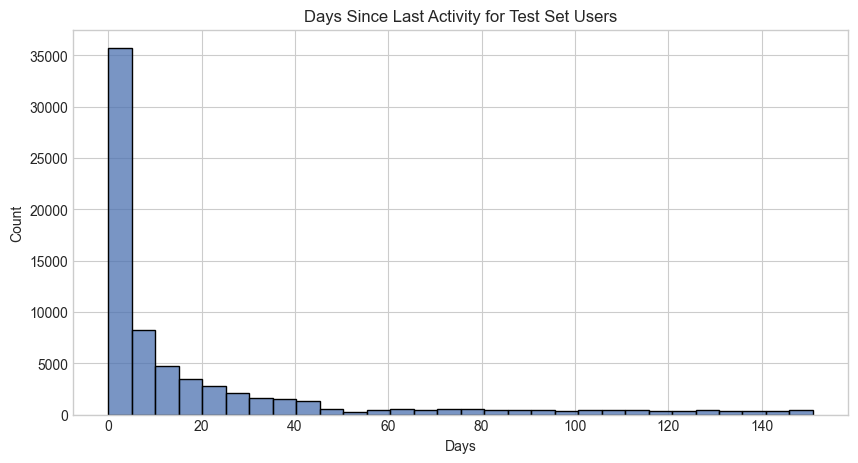

In [9]:
query_silent = f"""
WITH last_activity AS (
    SELECT 
        user_id,
        MAX(CAST(event_ts AS DATE)) as last_date
    FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
    GROUP BY 1
)
SELECT 
    DATE_DIFF('day', la.last_date, DATE '2026-04-09') as days_since_last_activity
FROM read_parquet('{PATHS['test_users']}') t
LEFT JOIN last_activity la ON t.user_id = la.user_id
"""
df_silent = con.execute(query_silent).df()

plt.figure(figsize=(10, 5))
sns.histplot(df_silent['days_since_last_activity'].dropna(), bins=30)
plt.title('Days Since Last Activity for Test Set Users')
plt.xlabel('Days')
plt.show()

## Next Phase: Detective-Style EDA for Feature Engineering
### 1. Sequential Pattern Mining (the "Path to Contact")
Identify common paths leading to positive events using window functions.

In [10]:
query_seq = f"""
WITH pos_users AS (
    SELECT DISTINCT user_id
    FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
    WHERE event_type IN ({positive_events_str})
    LIMIT 10000
),
user_events_sample AS (
    SELECT e.user_id, e.event_type, e.event_ts
    FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true) e
    JOIN pos_users pu ON e.user_id = pu.user_id
),
events_ordered AS (
  SELECT user_id, event_type, event_ts,
         LAG(event_type, 1) OVER (PARTITION BY user_id ORDER BY event_ts) as prev1,
         LAG(event_type, 2) OVER (PARTITION BY user_id ORDER BY event_ts) as prev2
  FROM user_events_sample
)
SELECT prev2, prev1, event_type as target, COUNT(*) as path_count
FROM events_ordered
WHERE event_type IN ({positive_events_str})
  AND prev1 IS NOT NULL
GROUP BY prev2, prev1, target
ORDER BY path_count DESC
LIMIT 20
"""
df_seq = con.execute(query_seq).df()
display(df_seq)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,prev2,prev1,target,path_count
0,other_interaction,other_interaction,other_interaction,604379
1,other_interaction,pageview,other_interaction,139942
2,pageview,other_interaction,other_interaction,134397
3,pageview,pageview,other_interaction,74928
4,view_phone,other_interaction,other_interaction,9856
5,other_interaction,view_phone,other_interaction,8904
6,other_interaction,other_interaction,view_phone,8729
7,other_interaction,pageview,view_phone,7546
8,NaN,pageview,other_interaction,6792
9,pageview,pageview,view_phone,6635


### 2. Temporal Clustering & Session Identification
Compute intra-session features such as duration, distinct items viewed, and category entropy.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

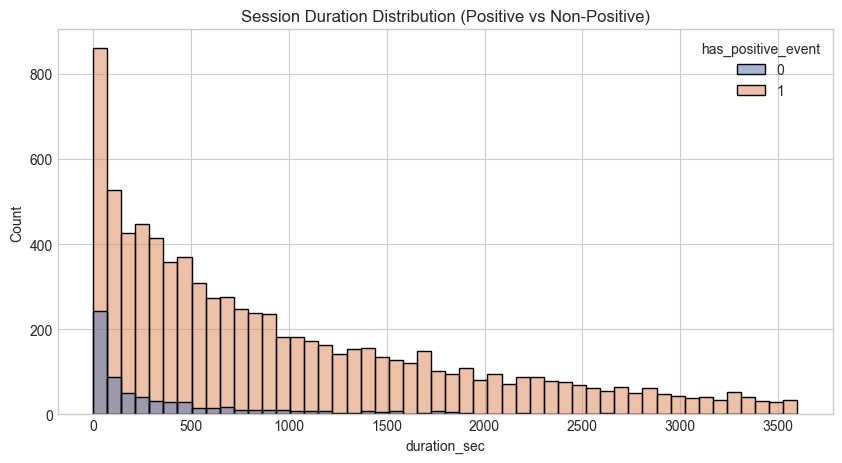

In [11]:
query_session = f"""
SELECT 
    session_id,
    user_id,
    MIN(event_ts) as session_start,
    MAX(event_ts) as session_end,
    DATE_DIFF('second', CAST(MIN(event_ts) AS TIMESTAMP), CAST(MAX(event_ts) AS TIMESTAMP)) as duration_sec,
    COUNT(DISTINCT item_id) as unique_items_viewed,
    MAX(CASE WHEN event_type IN ({positive_events_str}) THEN 1 ELSE 0 END) as has_positive_event
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
WHERE session_id IS NOT NULL AND session_id != ''
GROUP BY session_id, user_id
LIMIT 10000
"""
df_session = con.execute(query_session).df()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_session[df_session['duration_sec'] < 3600], x='duration_sec', hue='has_positive_event', bins=50)
plt.title('Session Duration Distribution (Positive vs Non-Positive)')
plt.show()


### 3. Negative Events Are Gold
Compute the ratio of positive events to views for each (user_id, item_id) pair.

In [12]:
query_neg = f"""
SELECT 
    user_id,
    item_id,
    COUNT(*) as total_views,
    SUM(CASE WHEN event_type IN ({positive_events_str}) THEN 1 ELSE 0 END) as total_positive
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
WHERE item_id IS NOT NULL AND item_id != ''
GROUP BY user_id, item_id
HAVING total_views > 5
LIMIT 10000
"""
df_neg = con.execute(query_neg).df()
df_neg['ratio_positive_to_views'] = df_neg['total_positive'] / df_neg['total_views']
display(df_neg.sort_values('total_views', ascending=False).head(10))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,item_id,total_views,total_positive,ratio_positive_to_views
7161,475aa19d30639b04f5645c4b507b3d0aa920e49acb580a...,1296a985331920161da35d11fa765b559478d77401dc53...,598,596.0,0.996656
6859,9ac596ff270cc7d53ced6a826d29523d4e4322803be248...,7290182749b243ddc125dcaa94a7e81bd425661ef2c9c8...,591,137.0,0.231810
4006,edc85a6cd4b203c6e4ec4484fe87fbf20a0e2eb5a666a5...,e4f3b90fe538495cdfd4921e35a93b70ffb14ca48cdc25...,466,452.0,0.969957
4092,9444bd1aadcf91892539e243283e0c0d848a27f94a6cfa...,91cdb69f46719aca579262a8f412c8ec8603d1e9343210...,369,354.0,0.959350
1114,66042d361eed833f8eedcd697e84675a1a86d00ef29944...,0622a72003f6e44f356e109998b8a6d04e616ad871231d...,340,331.0,0.973529
39,985a638b4efdeb66426026fb8048c0bc960182c503e2b5...,c9e5a593ab1a38c297c96e67e18ec996aedb6bb241dc0a...,318,69.0,0.216981
3619,d9f664043e6195cc831bc537dfe40bab34c05dc65fcb2b...,29ce0f2a42a12ea572c3e4a33a3b2888a461c55957fc2e...,295,274.0,0.928814
8476,99066e7ba87d59018086231776c480ed5cd8f58299a229...,52a89d44c95b317c0daaca80ba6d02fd500f437f0c23d4...,264,258.0,0.977273
1158,66042d361eed833f8eedcd697e84675a1a86d00ef29944...,86a6cb6397c19266ef982aa55172dd8c357f1037e4a98f...,263,259.0,0.984791
6164,83f735a7346f8c18bf2ba51597066d4af26aa0f5848108...,04cf4f4fffa99e614d32dcad537fb2b4ceb72b9421b65a...,254,247.0,0.972441


### 4. Non-Login Users vs Login Users
Compare positive event rate and engagement between logged-in and guest users.

In [13]:
query_login = f"""
SELECT 
    is_login,
    COUNT(*) as total_events,
    SUM(CASE WHEN event_type IN ({positive_events_str}) THEN 1 ELSE 0 END) as positive_events
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
GROUP BY is_login
"""
df_login = con.execute(query_login).df()
df_login['contact_rate'] = df_login['positive_events'] / df_login['total_events']
display(df_login)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,is_login,total_events,positive_events,contact_rate
0,non-login,59633247,43984447.0,0.737583
1,login,102098089,52197966.0,0.511253


### 5. Dwell Time Distribution & Intent
Plot dwell_time_sec for positive events vs non-positive events.

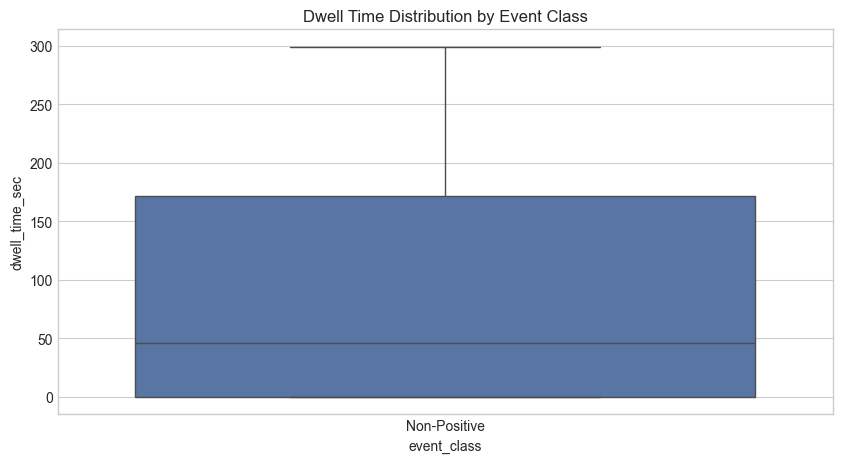

In [14]:
query_dwell = f"""
SELECT 
    CASE WHEN event_type IN ({positive_events_str}) THEN 'Positive' ELSE 'Non-Positive' END as event_class,
    dwell_time_sec
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
WHERE dwell_time_sec IS NOT NULL AND dwell_time_sec >= 0 AND dwell_time_sec < 300
LIMIT 100000
"""
df_dwell = con.execute(query_dwell).df()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_dwell, x='event_class', y='dwell_time_sec')
plt.title('Dwell Time Distribution by Event Class')
plt.show()


### 6. Query Text Analysis (NLP Lite)
Analyze the `query` column for high-intent keywords.

In [15]:
query_text = f"""
SELECT 
    query,
    COUNT(*) as freq
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
WHERE event_type = 'pageview' AND query IS NOT NULL AND query != ''
GROUP BY query
ORDER BY freq DESC
LIMIT 20
"""
df_text = con.execute(query_text).df()
display(df_text)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,query,freq
0,phòng trọ,205535
1,trọ,120749
2,cho thuê phòng trọ ở tp hồ chí minh,119019
3,nhà nguyên căn,63645
4,nhà trọ,60926
5,mặt bằng,53553
6,none,53196
7,chung cư,33139
8,cho thuê phòng trọ,25096
9,cho thuê nhà ở ở tp hồ chí minh,23799


### 7. Listing Quality Score
Combine listing attributes and historical positive event rate.

In [16]:
query_quality = f"""
WITH listing_stats AS (
    SELECT 
        item_id,
        COUNT(*) as total_views,
        SUM(CASE WHEN event_type IN ({positive_events_str}) THEN 1 ELSE 0 END) as positive_events
    FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
    WHERE item_id IS NOT NULL AND item_id != ''
    GROUP BY item_id
)
SELECT 
    l.item_id,
    l.total_views,
    l.positive_events,
    (l.positive_events + 5.0) / (l.total_views + 10.0) as smoothed_contact_rate
FROM listing_stats l
WHERE l.total_views > 10
ORDER BY smoothed_contact_rate DESC
LIMIT 10
"""
df_quality = con.execute(query_quality).df()
display(df_quality)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,item_id,total_views,positive_events,smoothed_contact_rate
0,2fade8c7e185aedc594c8dc73b3b707d77021b428c0700...,1018,1018.0,0.995136
1,77235f3f251c3692fbd18aad9f3af632df8926e767a7aa...,683,683.0,0.992785
2,82cbdcd11903841cc34df6d1f260b0330fd12d25e00fcc...,656,656.0,0.992492
3,67ff437e7183eadbef4866546121d01fa3224c2d5d2da2...,634,634.0,0.992236
4,3af61a76f0c2ecb749c42a30130491a5cc859a70f1a697...,582,582.0,0.991554
5,e8fc7fb50f3985038aa236dc12f357b805e020a922d371...,566,566.0,0.991319
6,8626d3f50edf040d6f532728f183b68052f2f60fff5412...,534,534.0,0.990809
7,d24a0cffc70fdb12aef415998a5a0eeb1596d175c6f41e...,530,530.0,0.990741
8,3424cda9ad3d64406e93baa2bd6a663769ccdc145c1031...,494,494.0,0.990079
9,d4a882c942d8b8a966a0c80b3e454dcf94fda50b1350af...,494,494.0,0.990079


### 8. Time Since Last Interaction (Recency)
Compute recency buckets for users.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

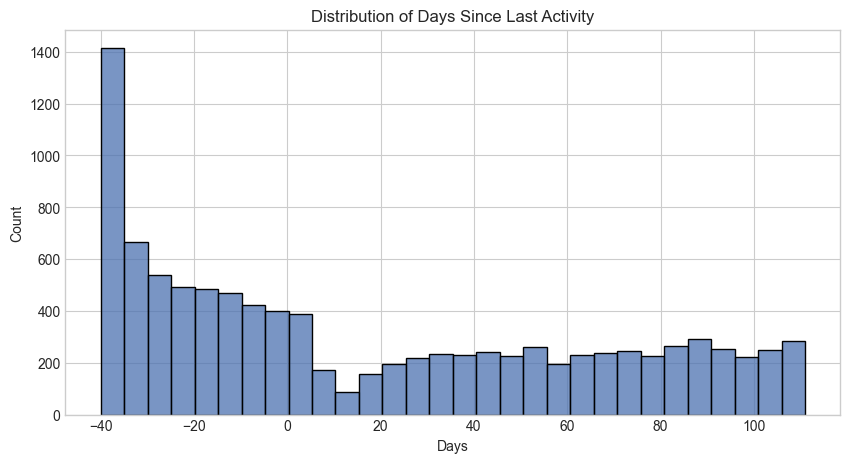

In [17]:
query_recency = f"""
SELECT 
    user_id,
    MAX(event_ts) as last_interaction,
    DATE_DIFF('day', CAST(MAX(event_ts) AS TIMESTAMP), CAST('2026-02-28' AS TIMESTAMP)) as days_since_last_activity
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
GROUP BY user_id
LIMIT 10000
"""
df_recency = con.execute(query_recency).df()

plt.figure(figsize=(10, 5))
sns.histplot(df_recency['days_since_last_activity'], bins=30)
plt.title('Distribution of Days Since Last Activity')
plt.xlabel('Days')
plt.show()


### 9. Cyclical Time Features & Holidays
Impact of Tet Holiday.

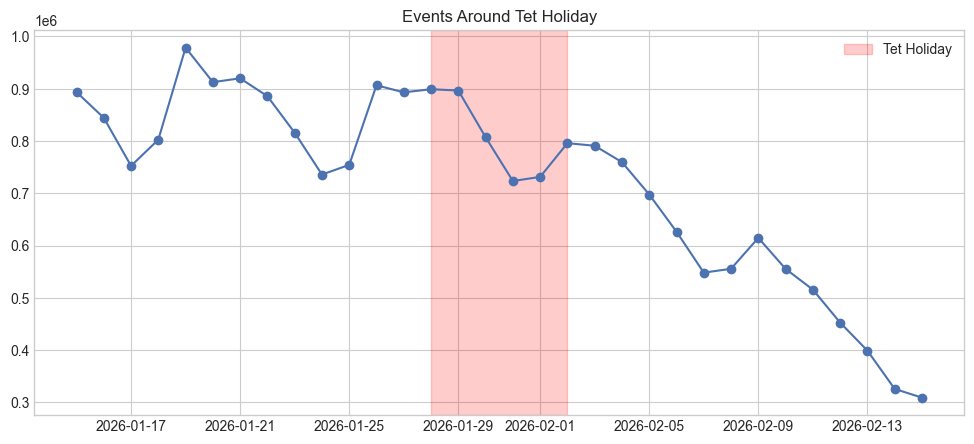

In [18]:
query_holiday = f"""
SELECT 
    CAST(event_ts AS DATE) as event_date,
    COUNT(*) as total_events
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true)
WHERE CAST(event_ts AS DATE) BETWEEN '2026-01-15' AND '2026-02-15'
GROUP BY 1
ORDER BY 1
"""
df_holiday = con.execute(query_holiday).df()

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(df_holiday['event_date']), df_holiday['total_events'], marker='o')
plt.axvspan('2026-01-28', '2026-02-02', color='red', alpha=0.2, label='Tet Holiday')
plt.title('Events Around Tet Holiday')
plt.legend()
plt.show()


### 10. Interaction Between User and Listing Categories
Analyze user category preferences.

In [19]:
# Note: Needs dim_listing join for accurate categories if not present in user_events.
# Assuming category is not directly in user_events, we join with dim_listing:
query_user_cat = f"""
SELECT 
    e.user_id,
    l.category,
    COUNT(*) as interaction_count
FROM read_parquet('{PATHS['user_events']}', hive_partitioning=true) e
JOIN read_parquet('{PATHS['dim_listing']}') l ON e.item_id = l.item_id
WHERE e.user_id IS NOT NULL AND l.category IS NOT NULL
GROUP BY e.user_id, l.category
ORDER BY interaction_count DESC
LIMIT 20
"""
try:
    df_user_cat = con.execute(query_user_cat).df()
    display(df_user_cat)
except Exception as e:
    print("Could not compute user-category interactions. Ensure item_id matching and dim_listing schema:", e)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_id,category,interaction_count
0,66042d361eed833f8eedcd697e84675a1a86d00ef29944...,1040,33688
1,bb2629f2e8627ac239973c99eae41761ba903e6c1698bd...,1020,24620
2,9091e2cd04320dd8ad277b507ca4a7ea08c92ee12e4acd...,1020,20558
3,60c3f6b43fef0b398b84260c15cdcd84c427aef80a994d...,1020,17264
4,2bdd57da57a9e0ed0fef2fc4e47557c6dbfa95f2c32471...,1020,16222
5,de025acff17e0e7e1fe27f9094689b1a146358d905a19a...,1020,15631
6,d8939c3996ee951d596853b897ce958be8137cd2603576...,1020,15314
7,aa9399dfc622979d4950c0b7bee20378fd8128961f128a...,1020,14378
8,048ce32aec266f650edf05f5bb7feb0e31e1748898fc54...,1020,13769
9,3bcb47094b11e56ea6684b73aa1fd48d2069a8805267db...,1020,13640
